# Feature Engineering — The Financial Stress Score
### Hari Vykuntapu | MS Artificial Intelligence, Southwest Baptist University

---

## The Core Idea: A Composite Financial Stress Score

The EDA showed that income, healthcare affordability, and employment each individually correlate with heart disease. But each is a partial picture on its own. Someone can have low income and still have employer coverage. Someone can be unemployed but have savings.

The **Financial Stress Score (FSS)** captures the cumulative weight of all three pressures — a single 0–1 number where higher means more economic strain:

$$FSS = (\text{income\_inverse\_norm} \times 0.4) + (\text{medcost\_burden} \times 0.35) + (\text{unemployment\_flag} \times 0.25)$$

**Why these weights?**
- **Income (40%)** — the most fundamental determinant of financial security; everything else tends to follow
- **Healthcare affordability (35%)** — the most direct barrier to catching cardiovascular problems early; weighted nearly as high as income because the mechanism is so direct
- **Unemployment (25%)** — real and meaningful, but secondary to the other two for this specific health outcome


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 150

os.makedirs('../outputs/eda', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/processed/brfss_cleaned.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(df.head())

Loaded: 433,153 rows x 9 columns
   MICHD  INCOME2  MEDCOST  EMPLOY1   _BMI5  SMOKE100  _AGE80  SEX  DIABETE3
0      0      3.0        0      3.0  4018.0       1.0    63.0  2.0       3.0
1      0      1.0        1      2.0  2509.0       1.0    52.0  2.0       3.0
2      0      8.0        1      3.0  2819.0       2.0    63.0  2.0       3.0
3      0     77.0        0      3.0  2437.0       2.0    61.0  2.0       3.0
4      0      6.0        0      1.0  2652.0       2.0    73.0  2.0       3.0


## 2. Component 1 — Income, Inverted

CDC codes INCOME2 from 1 (under $10K/year) to 8 (over $75K). Higher = wealthier, which is backwards for a stress score. The fix: `(8 - INCOME2) / 7` flips it so that 1.0 = lowest earners and 0.0 = highest. Now it reads as financial pressure rather than income level.


In [3]:
if 'INCOME2' in df.columns:
    income_valid = df['INCOME2'].between(1, 8)
    df['income_inverse_norm'] = np.nan
    df.loc[income_valid, 'income_inverse_norm'] = (
        (8 - df.loc[income_valid, 'INCOME2']) / 7.0
    )
    # Fill NaN with median
    df['income_inverse_norm'] = df['income_inverse_norm'].fillna(df['income_inverse_norm'].median())
    print('income_inverse_norm summary:')
    print(df['income_inverse_norm'].describe().round(4))

income_inverse_norm summary:
count    433153.0000
mean          0.3058
std           0.2806
min           0.0000
25%           0.0000
50%           0.2857
75%           0.4286
max           1.0000
Name: income_inverse_norm, dtype: float64


## 3. Component 2 — Healthcare Cost Barrier

Already binary from notebook 01: 1 = skipped care because of cost, 0 = didn't. This is the most direct connection between financial stress and undetected heart disease. People who can't afford the doctor are the same people who never find out their blood pressure is dangerously high, or that they're pre-diabetic. That's why it gets 35% weight in the FSS — nearly as much as income itself.


In [4]:
if 'MEDCOST' in df.columns:
    df['medcost_burden'] = df['MEDCOST'].fillna(0).astype(float)
    print('medcost_burden distribution:')
    print(df['medcost_burden'].value_counts())

medcost_burden distribution:
medcost_burden
0.0    390646
1.0     42507
Name: count, dtype: int64


## 4. Component 3 — Unemployment Flag

From notebook 01: EMPLOY1 is 1 (employed), 2 (unemployed), 3 (other). Binary-encoding unemployment: 1 if actively out of work, 0 otherwise. Unemployment hits income and insurance at the same time — which is why it's in the FSS even though income is already capturing some of that pressure. The overlap is intentional: cumulative stress, not mutually exclusive factors.


In [5]:
if 'EMPLOY1' in df.columns:
    df['unemployment_flag'] = (df['EMPLOY1'] == 2).astype(float)
    print('unemployment_flag distribution:')
    print(df['unemployment_flag'].value_counts())

unemployment_flag distribution:
unemployment_flag
0.0    414961
1.0     18192
Name: count, dtype: int64


## 5. Construct the Financial Stress Score

All three components go in. I want to see the distribution once assembled — whether it clusters around certain values or spreads evenly across 0–1.


In [6]:
df['financial_stress_score'] = (
    (df['income_inverse_norm'] * 0.40) +
    (df['medcost_burden'] * 0.35) +
    (df['unemployment_flag'] * 0.25)
)

print('Financial Stress Score summary:')
print(df['financial_stress_score'].describe().round(4))
print()
print(f'Score range: {df["financial_stress_score"].min():.4f} – {df["financial_stress_score"].max():.4f}')

Financial Stress Score summary:
count    433153.0000
mean          0.1672
std           0.1827
min           0.0000
25%           0.0000
50%           0.1143
75%           0.2286
max           1.0000
Name: financial_stress_score, dtype: float64

Score range: 0.0000 – 1.0000


## 6. Score Bucketing — Low / Medium / High

Equal-width buckets at 0.33 and 0.66 for interpretability. The thresholds are somewhat arbitrary — what matters is whether the high-stress group shows a meaningfully different heart disease rate than the low-stress group.


In [7]:
def bucket_stress(score):
    if score < 0.33:
        return 'Low'
    elif score < 0.66:
        return 'Medium'
    else:
        return 'High'

df['stress_bucket'] = df['financial_stress_score'].apply(bucket_stress)
print('Stress bucket distribution:')
print(df['stress_bucket'].value_counts())
print()
print('Heart disease rate by stress bucket:')
print((df.groupby('stress_bucket')['MICHD'].mean() * 100).round(2))

Stress bucket distribution:
stress_bucket
Low       353743
Medium     68665
High       10745
Name: count, dtype: int64

Heart disease rate by stress bucket:


stress_bucket
High      13.65
Low        8.20
Medium    11.31
Name: MICHD, dtype: float64


## 7. Heart Disease Rate by Financial Stress Bucket

The key validation chart for the FSS. A flat pattern here would be a problem — it would mean the composite score isn’t actually capturing cardiovascular risk. A rising monotonic pattern would confirm it’s doing its job.


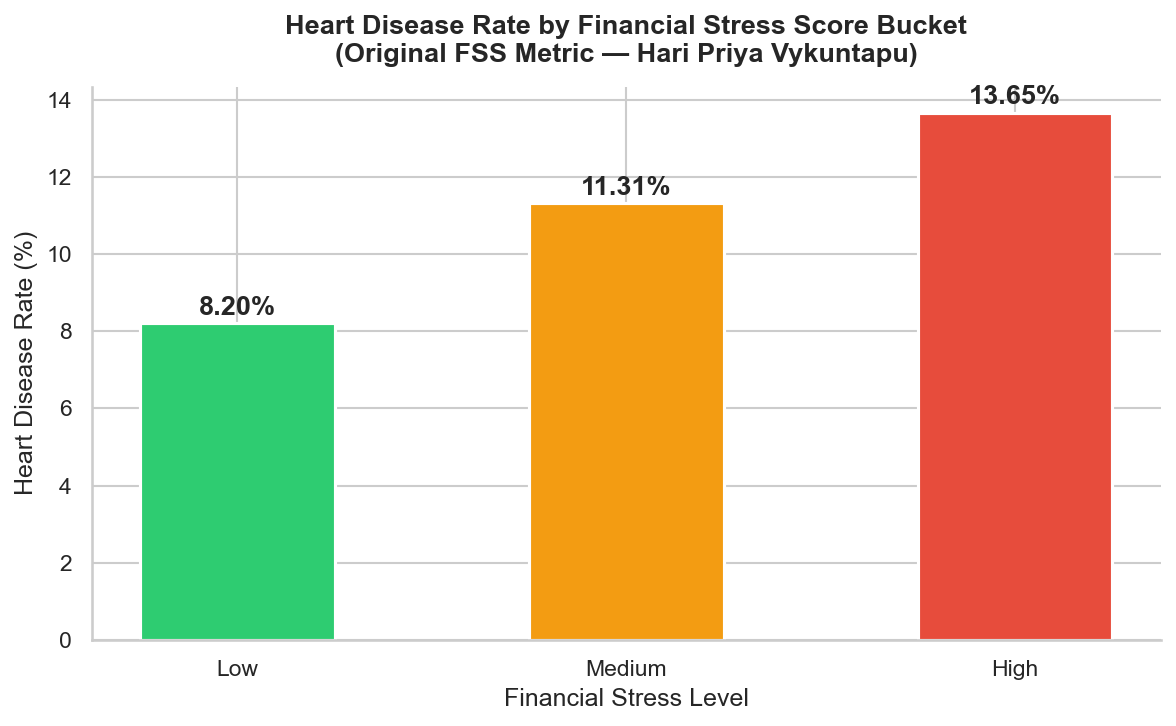

Saved: outputs/eda/hd_rate_by_stress_bucket.png


In [8]:
bucket_order = ['Low', 'Medium', 'High']
bucket_hd = df.groupby('stress_bucket')['MICHD'].mean() * 100
bucket_hd = bucket_hd.reindex(bucket_order)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(bucket_hd.index, bucket_hd.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, bucket_hd.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_title('Heart Disease Rate by Financial Stress Score Bucket\n(Original FSS Metric — Hari Vykuntapu)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Financial Stress Level', fontsize=12)
ax.set_ylabel('Heart Disease Rate (%)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/eda/hd_rate_by_stress_bucket.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/eda/hd_rate_by_stress_bucket.png')

## 8. Correlation Heatmap

Checking how the FSS components relate to each other and to the target. I want some correlation with MICHD (that’s the point), but not so much intercorrelation between components that they’re measuring the same thing twice.


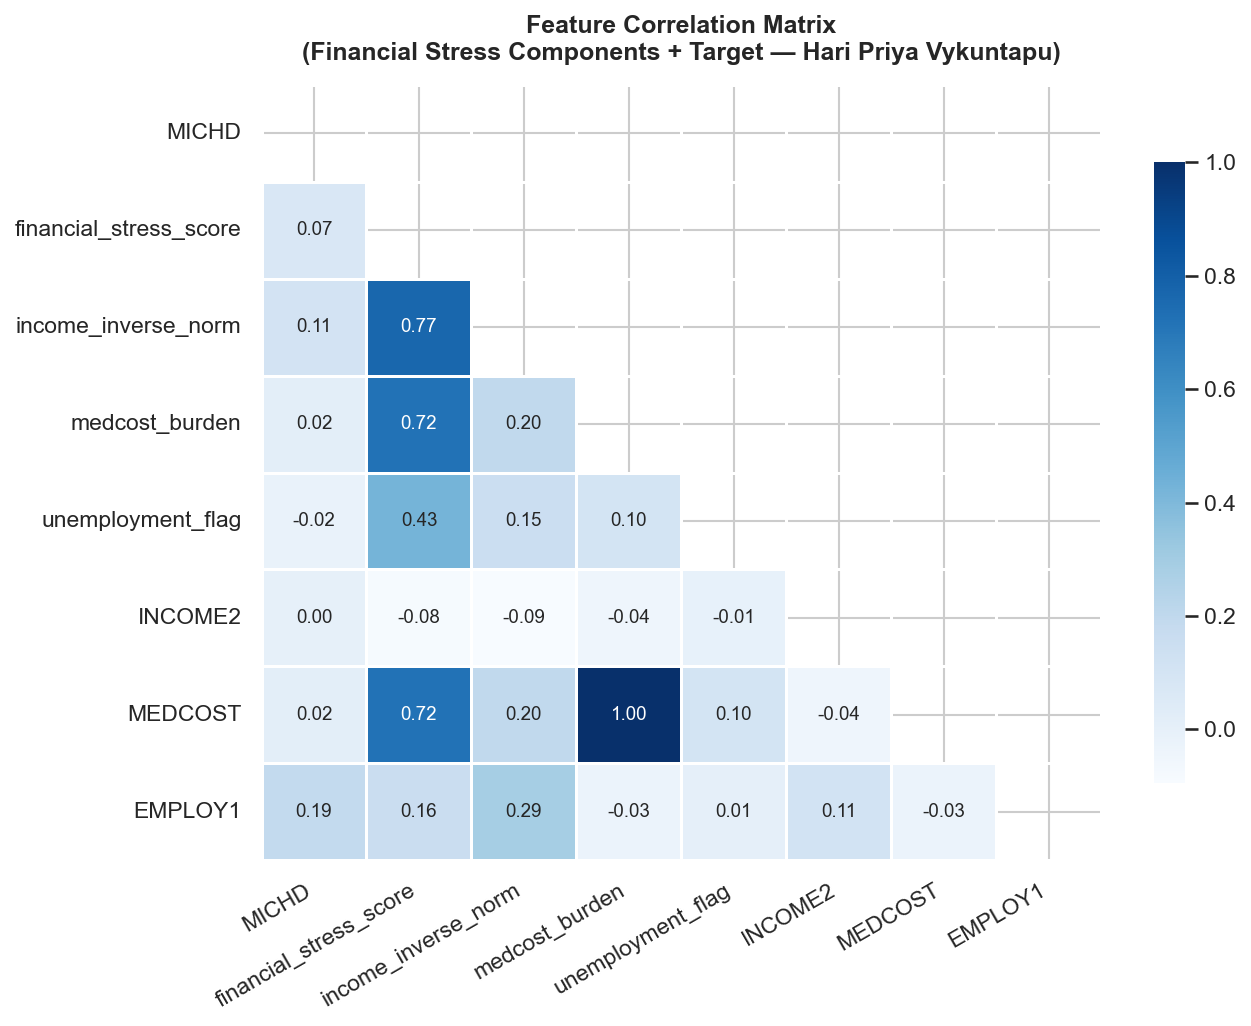

Saved: outputs/eda/correlation_heatmap.png


In [9]:
feature_cols = ['MICHD', 'financial_stress_score', 'income_inverse_norm', 'medcost_burden',
                'unemployment_flag', 'INCOME2', 'MEDCOST', 'EMPLOY1']
available_features = [c for c in feature_cols if c in df.columns]

corr_df = df[available_features].dropna()

fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix\n(Financial Stress Components + Target — Hari Vykuntapu)',
             fontsize=12, fontweight='bold', pad=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/eda/correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/eda/correlation_heatmap.png')

## 9. Save Engineered Feature Dataset

In [10]:
output_cols = ['MICHD', 'financial_stress_score', 'stress_bucket',
               'income_inverse_norm', 'medcost_burden', 'unemployment_flag',
               'INCOME2', 'MEDCOST', 'EMPLOY1', '_BMI5', 'SMOKE100', '_AGE80', 'SEX', 'DIABETE3']

output_cols = [c for c in output_cols if c in df.columns]
df_out = df[output_cols].copy()

# Fill remaining NaNs with column medians for numeric features
for col in df_out.select_dtypes(include=[np.number]).columns:
    df_out[col] = df_out[col].fillna(df_out[col].median())

df_out.to_csv('../data/processed/brfss_features.csv', index=False)
print(f'Saved: data/processed/brfss_features.csv')
print(f'Shape: {df_out.shape[0]:,} rows x {df_out.shape[1]} columns')
print(f'\nColumns saved:')
for c in df_out.columns:
    print(f'  {c}')

Saved: data/processed/brfss_features.csv
Shape: 433,153 rows x 14 columns

Columns saved:
  MICHD
  financial_stress_score
  stress_bucket
  income_inverse_norm
  medcost_burden
  unemployment_flag
  INCOME2
  MEDCOST
  EMPLOY1
  _BMI5
  SMOKE100
  _AGE80
  SEX
  DIABETE3


---
## Feature Engineering Summary

The FSS shows a monotonic relationship with heart disease rates across buckets. The correlation heatmap confirms the components aren’t redundant with each other. The score is ready to go into training as a feature.

*— Hari Vykuntapu, MS AI, Southwest Baptist University*
